# 03b: Assess BOM/NCI irradiance coverage

Inventory the BOM table, map substation coordinates to the nearest BOM grid point, and measure monthly coverage.

In [1]:
from __future__ import annotations
import calendar, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p/'src'/'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT/'src'))
from ausgrid_analysis.analysis_cohort import site_eligibility_path
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import connect
from ausgrid_analysis.irradiance_coverage import (
    GeographicBounds, bom_inventory_sql, bom_locations_sql, bom_mapped_coverage_sql,
    nearest_grid_mapping, irradiance_location_map_path, irradiance_coverage_path,
    write_frame_parquet,
)
from ausgrid_analysis.schemas import sql_string
pd.set_option('display.max_columns', 100); plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
CONFIG_PATH = PROJECT_ROOT/'analysis.toml'
config = load_config(CONFIG_PATH, check_inputs=False)
con = connect(config)
eligibility = con.execute(f'SELECT * FROM read_parquet({sql_string(site_eligibility_path(config))})').fetchdf()
eligible = eligibility.loc[eligibility.eligible_for_irradiance_assessment].copy()
assert not eligible.empty, 'Run notebook 03a first.'
MONTHS = [(2024,m) for m in range(8,13)] + [(2025,m) for m in range(1,8)]
bounds = GeographicBounds.from_sites(eligible, padding_degrees=0.1)
print('Eligible sites:', len(eligible)); print('BOM query bounds:', bounds)

Eligible sites: 410
BOM query bounds: GeographicBounds(minimum_latitude=-34.185489600000004, maximum_latitude=-32.4138152, minimum_longitude=150.8883979, maximum_longitude=152.05136099999999)


## Athena connection and query preview

reuses the existing `/shared/aws_config.py` helper. 

Need to run `aws sso login --profile ciccada` first.

In [3]:
BMS_REVIEW_ROOT = PROJECT_ROOT.parent/'bms_sa_review'
AWS_SHARED = BMS_REVIEW_ROOT/'shared'
assert AWS_SHARED.is_dir(), f'Expected existing AWS helper at {AWS_SHARED}'
sys.path.insert(0, str(AWS_SHARED))
from aws_config import aq
inventory_query = bom_inventory_sql(bounds, MONTHS)
locations_query = bom_locations_sql(bounds, MONTHS)
print(inventory_query)

SELECT
            year,
            month,
            count(*) AS n_rows,
            count(DISTINCT concat(
                cast(latitude AS varchar), '|', cast(longitude AS varchar)
            )) AS n_grid_points,
            min(time) AS first_time,
            max(time) AS last_time,
            count_if(surface_global_irradiance IS NULL) AS null_ghi,
            count_if(quality_mask IS NULL) AS null_quality_mask
        FROM solar
        WHERE ((year = 2024 AND month = 8) OR (year = 2024 AND month = 9) OR (year = 2024 AND month = 10) OR (year = 2024 AND month = 11) OR (year = 2024 AND month = 12) OR (year = 2025 AND month = 1) OR (year = 2025 AND month = 2) OR (year = 2025 AND month = 3) OR (year = 2025 AND month = 4) OR (year = 2025 AND month = 5) OR (year = 2025 AND month = 6) OR (year = 2025 AND month = 7))
          AND latitude BETWEEN -34.18548960 AND -32.41381520 AND longitude BETWEEN 150.88839790 AND 152.05136100
        GROUP BY year, month
        ORDER BY year, mon

In [4]:
BOM_QUERY_CONFIRMATION = 'RUN BOM COVERAGE AUDIT'  # Change to: RUN BOM COVERAGE AUDIT
assert BOM_QUERY_CONFIRMATION == 'RUN BOM COVERAGE AUDIT', 'Athena queries remain locked.'

In [5]:
inventory = aq(inventory_query, database='bom_nci')
grid_locations = aq(locations_query, database='bom_nci')
display(inventory); display(grid_locations.head())
assert set(MONTHS).issubset(set(zip(inventory.year.astype(int), inventory.month.astype(int)))), 'One or more telemetry months are absent from BOM inventory.'

,year,month,n_rows,n_grid_points,first_time,last_time,null_ghi,null_quality_mask
0,2024,8,4788095,2387,2024-08-01,2024-08-31 23:50:00,0,0
1,2024,9,5052053,2387,2024-09-01,2024-09-30 23:50:00,0,0
2,2024,10,5671508,2387,2024-10-01,2024-10-31 23:50:00,0,0
3,2024,11,5821540,2387,2024-11-01,2024-11-30 23:50:00,0,0
4,2024,12,6267950,2387,2024-12-01,2024-12-31 23:50:00,0,0
5,2025,1,6142924,2387,2025-01-01,2025-01-31 23:50:00,0,0
6,2025,2,5238912,2387,2025-02-01,2025-02-28 23:50:00,0,0
7,2025,3,5370516,2387,2025-03-01,2025-03-31 23:50:00,0,0
8,2025,4,4757937,2387,2025-04-01,2025-04-30 23:50:00,0,0
9,2025,5,4552461,2387,2025-05-01,2025-05-31 23:50:00,0,0


,latitude,longitude,postcode
0,-34.18,150.96,2508
1,-34.18,150.98,2508
2,-34.18,151.00,2508
3,-34.18,151.02,2508
4,-34.18,151.04,2508


## Spatial mapping

Dataset contains substation coordinates, not customer coordinates. Distance therefore measures substation-to-BOM-grid separation and does not validate site location.

,quality,n_sites
0,good,410


count    410.000000
mean       0.770779
std        0.277865
min        0.075393
50%        0.797023
90%        1.101698
95%        1.210400
99%        1.322850
max        1.369381
Name: distance_km, dtype: float64

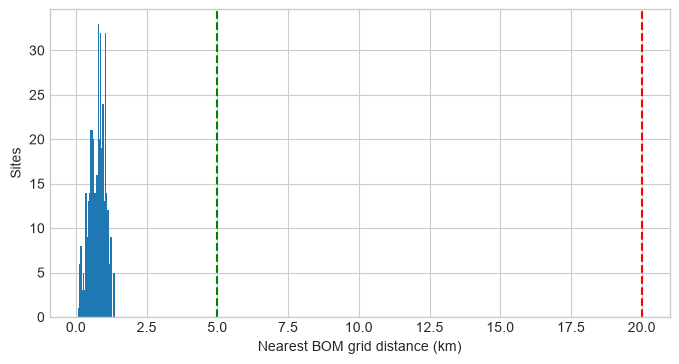

WindowsPath('C:/Users/z3553082/OneDrive - UNSW/Documents/CICCADA - Data/Ausgrid/derived/irradiance/site_to_bom_grid.parquet')

In [6]:
location_map = nearest_grid_mapping(eligible[['serial','sub_lat','sub_long']], grid_locations)
display(location_map.spatial_mapping_quality.value_counts().rename_axis('quality').reset_index(name='n_sites'))
display(location_map.distance_km.describe(percentiles=[.5,.9,.95,.99]))
fig, ax = plt.subplots(figsize=(8,4)); location_map.distance_km.hist(ax=ax, bins=30)
ax.axvline(5, color='green', linestyle='--'); ax.axvline(20, color='red', linestyle='--')
ax.set(xlabel='Nearest BOM grid distance (km)', ylabel='Sites'); plt.show()
assert not location_map.spatial_mapping_quality.eq('poor').any(), 'Poor spatial matches require review.'
write_frame_parquet(config, location_map, irradiance_location_map_path(config), overwrite=True)

## Monthly coverage at mapped grid points

In [7]:
'''points = list(location_map[['bom_latitude','bom_longitude']].drop_duplicates().itertuples(index=False, name=None))
coverage_parts = []
for start in range(0, len(points), 40):
    query = bom_mapped_coverage_sql(points[start:start+40], MONTHS)
    coverage_parts.append(aq(query, database='bom_nci'))
coverage = pd.concat(coverage_parts, ignore_index=True)
coverage['expected_10min_timestamps'] = coverage.apply(lambda r: calendar.monthrange(int(r.year), int(r.month))[1] * 24 * 6, axis=1)
coverage['timestamp_coverage'] = coverage.n_timestamps / coverage.expected_10min_timestamps
coverage['ghi_null_fraction'] = coverage.null_ghi / coverage.n_rows
display(coverage[['timestamp_coverage','ghi_null_fraction','minimum_quality_mask','maximum_quality_mask','n_quality_mask_values']].describe(percentiles=[.01,.05,.5,.95,.99]))
display(coverage.groupby(['minimum_quality_mask','maximum_quality_mask'], dropna=False).agg(grid_months=('n_timestamps','size'), rows=('n_rows','sum'), mask_1_rows=('quality_mask_1_rows','sum')).reset_index())
display(coverage.nsmallest(20, 'timestamp_coverage'))
write_frame_parquet(config, coverage, irradiance_coverage_path(config), overwrite=True)'''

"points = list(location_map[['bom_latitude','bom_longitude']].drop_duplicates().itertuples(index=False, name=None))\ncoverage_parts = []\nfor start in range(0, len(points), 40):\n    query = bom_mapped_coverage_sql(points[start:start+40], MONTHS)\n    coverage_parts.append(aq(query, database='bom_nci'))\ncoverage = pd.concat(coverage_parts, ignore_index=True)\ncoverage['expected_10min_timestamps'] = coverage.apply(lambda r: calendar.monthrange(int(r.year), int(r.month))[1] * 24 * 6, axis=1)\ncoverage['timestamp_coverage'] = coverage.n_timestamps / coverage.expected_10min_timestamps\ncoverage['ghi_null_fraction'] = coverage.null_ghi / coverage.n_rows\ndisplay(coverage[['timestamp_coverage','ghi_null_fraction','minimum_quality_mask','maximum_quality_mask','n_quality_mask_values']].describe(percentiles=[.01,.05,.5,.95,.99]))\ndisplay(coverage.groupby(['minimum_quality_mask','maximum_quality_mask'], dropna=False).agg(grid_months=('n_timestamps','size'), rows=('n_rows','sum'), mask_1_rows=(

In [8]:
points = list(
    location_map[
        ["bom_latitude", "bom_longitude"]
    ].drop_duplicates().itertuples(index=False, name=None)
)

coverage_parts = []
for start in range(0, len(points), 40):
    query = bom_mapped_coverage_sql(
        points[start : start + 40],
        MONTHS,
    )
    coverage_parts.append(aq(query, database="bom_nci"))

coverage = pd.concat(coverage_parts, ignore_index=True)

# The BOM ten-minute irradiance product contains daylight observations only.
# This fraction is descriptive of day length; it is not a completeness metric.
coverage["all_day_10min_slots"] = coverage.apply(
    lambda row: (
        calendar.monthrange(int(row.year), int(row.month))[1]
        * 24
        * 6
    ),
    axis=1,
)
coverage["all_day_slot_fraction"] = (
    coverage["n_timestamps"] / coverage["all_day_10min_slots"]
)

# Compare grid points within the same month. This allows daylight duration to
# vary seasonally while detecting points with materially fewer observations.
coverage["month_reference_daylight_timestamps"] = (
    coverage.groupby(["year", "month"])["n_timestamps"].transform("max")
)
coverage["relative_daylight_coverage"] = (
    coverage["n_timestamps"]
    / coverage["month_reference_daylight_timestamps"]
)
coverage["duplicate_rows"] = (
    coverage["n_rows"] - coverage["n_timestamps"]
)
coverage["ghi_null_fraction"] = (
    coverage["null_ghi"] / coverage["n_rows"]
)

display(
    coverage[
        [
            "all_day_slot_fraction",
            "relative_daylight_coverage",
            "ghi_null_fraction",
            "minimum_quality_mask",
            "maximum_quality_mask",
            "n_quality_mask_values",
        ]
    ].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
)

display(
    coverage.groupby(
        ["minimum_quality_mask", "maximum_quality_mask"],
        dropna=False,
    )
    .agg(
        grid_months=("n_timestamps", "size"),
        rows=("n_rows", "sum"),
        mask_1_rows=("quality_mask_1_rows", "sum"),
    )
    .reset_index()
)

display(coverage.nsmallest(20, "relative_daylight_coverage"))

write_frame_parquet(
    config,
    coverage,
    irradiance_coverage_path(config),
    overwrite=True,
)

,all_day_slot_fraction,relative_daylight_coverage,ghi_null_fraction,minimum_quality_mask,maximum_quality_mask,n_quality_mask_values
count,1344.0,1344.0,1344.0,1344.0,1344.0,1344.0
mean,0.497257,0.995697,0.0,1.0,1.0,1.0
std,0.06193,0.004098,0.0,0.0,0.0,0.0
min,0.405324,0.982053,0.0,1.0,1.0,1.0
1%,0.405787,0.983174,0.0,1.0,1.0,1.0
5%,0.409757,0.987562,0.0,1.0,1.0,1.0
50%,0.496931,0.997353,0.0,1.0,1.0,1.0
95%,0.5889,0.99958,0.0,1.0,1.0,1.0
99%,0.592294,1.0,0.0,1.0,1.0,1.0
max,0.592518,1.0,0.0,1.0,1.0,1.0


,minimum_quality_mask,maximum_quality_mask,grid_months,rows,mask_1_rows
0,1,1,1344,2925949,2925949


,latitude,longitude,year,month,n_rows,n_timestamps,first_time,last_time,null_ghi,null_quality_mask,minimum_quality_mask,maximum_quality_mask,n_quality_mask_values,quality_mask_1_rows,usable_ghi_rows,all_day_10min_slots,all_day_slot_fraction,month_reference_daylight_timestamps,relative_daylight_coverage,duplicate_rows,ghi_null_fraction
10,-34.08,151.02,2025,6,1751,1751,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1751,1751,4320,0.405324,1783,0.982053,0,0.0
22,-34.06,151.00,2025,6,1751,1751,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1751,1751,4320,0.405324,1783,0.982053,0,0.0
70,-34.00,151.06,2025,6,1751,1751,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1751,1751,4320,0.405324,1783,0.982053,0,0.0
34,-34.06,151.12,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
46,-34.06,151.14,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
58,-34.04,151.16,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
94,-33.96,151.12,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
490,-34.04,151.14,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
970,-34.04,151.00,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0
982,-34.04,151.12,2025,6,1752,1752,2025-06-01,2025-06-30 23:50:00,0,0,1,1,1,1752,1752,4320,0.405556,1783,0.982614,0,0.0


WindowsPath('C:/Users/z3553082/OneDrive - UNSW/Documents/CICCADA - Data/Ausgrid/derived/irradiance/bom_monthly_coverage.parquet')

## Decision gate

Passing this gate only authorises decomposition experiments. It does not make the BOM series site-level irradiance or make net-meter power an inverter measurement.

In [9]:
# Change only after reviewing every table above to:
# ACCEPT IRRADIANCE MAPPING FOR DECOMPOSITION EXPERIMENTS
IRRADIANCE_GATE_DECISION = "ACCEPT IRRADIANCE MAPPING FOR DECOMPOSITION EXPERIMENTS"


assert (
    IRRADIANCE_GATE_DECISION
    == "ACCEPT IRRADIANCE MAPPING FOR DECOMPOSITION EXPERIMENTS"
)

expected_grid_months = len(points) * len(MONTHS)
assert len(coverage) == expected_grid_months, (
    "One or more mapped grid-months are absent."
)
assert not coverage.duplicated(
    ["latitude", "longitude", "year", "month"]
).any()
assert coverage["duplicate_rows"].sum() == 0, (
    "Duplicate BOM rows exist within a grid point/timestamp."
)
assert coverage["relative_daylight_coverage"].min() >= 0.98, (
    "A mapped grid-month has low coverage relative to other mapped "
    "grid points in that month."
)
assert coverage["ghi_null_fraction"].max() <= 0.05, (
    "At least one mapped grid-month has more than 5% null GHI."
)

con.close()
print(
    "Irradiance coverage gate passed; "
    "decomposition experiments may be designed."
)

Irradiance coverage gate passed; decomposition experiments may be designed.
